# Appendix D figures — nearest-neighbor Ising (`supp_fig` + `fig4`)

Reproduces the two Appendix-D Ising figures from the small summary dicts committed in this folder
(`hld_dict_for_last_figs.jld2`, `all_temp_level_dict.jld2`). 

The Appendix-C figure `nn_ising_kappa_C` lives in its own notebook, `nn_ising_kappa.ipynb`

- **`supp_fig_working-new.pdf`** (Appendix D) — mean-over-replicates D_KL(p_D‖p_T)∩Λ_4 and
  D_KL(q̂‖p_T)∩Λ_4 vs training-set size M, for several ground-truth temperatures (inset: the
  same without the Λ_4 restriction). Data: `all_temp_level_dict.jld2` (per-temperature per-level
  D_KL sweeps, T = 2.3, 2.4, …, 4.4).
- **`fig4-working-latest.pdf`** data panels (Appendix D) — per-state probabilities (p_T, q̂, p_D),
  per-state reversed-D_KL contribution, and the per-energy-level D_KL decomposition. Data:
  `hld_dict_for_last_figs.jld2` (T=2.3 experiment) + `all_temp_level_dict.jld2`.

The per-level D_KL data in `all_temp_level_dict.jld2` was generated by an independent
re-sampling/re-fitting sweep, NOT from the raw sweeps on Hugging Face, so it is committed directly.


In [1]:
using DrWatson
@quickactivate "temp-tune"

# PyPlot + Printf must load before the src include (macros expand at include time).
using JLD2, PyPlot, Statistics, Printf, StatsBase

include(srcdir("matplotlib_helpers.jl"))   # set_size_for_paper, setup_notebook_for_paper, using_Py

setup_notebook_for_paper()
using_Py(true)

pe = pyimport("matplotlib.patheffects")    # path-effects used by supp_fig

PyObject <module 'matplotlib.patheffects' from '/Users/pfields/Git/temp-tune/.conda/lib/python3.12/site-packages/matplotlib/patheffects.py'>

In [7]:
set_plot_style_for_paper()

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



In [23]:
# --- nn_ising_kappa_C panels a–d (ported from proteins/temp_analysis/ml_fitting_3.ipynb) ---

"""
Panels a–d of appendix figure `nn_ising_kappa_C.pdf`: per-energy-level reversed
D_KL(q̂_{τ=1}||p_T) and its τ-derivative at τ=1, for the low-T (T=2.3) and high-T (T=4.0)
single experiments stored in `hld[:low]` / `hld[:high]`. A positive derivative ⇒ lower τ;
negative ⇒ raise τ. `ax` is a length-4 (2×2) axes container.
"""
function plot_dkl_et_al(ax, hld)
    lvl_resort = hld[:low][:lvl_resort]
    xx = collect(0:length(lvl_resort) - 1)
    iiddxxx = 2:10   # excited levels shown in the paper

    ax[1].bar(xx[iiddxxx], hld[:low][:dkl_q_p_per_lev][iiddxxx],        color="k")
    ax[2].bar(xx[iiddxxx], hld[:low][:DdklDtau_q_p_per_level][iiddxxx], color="k")
    ax[3].bar(xx[iiddxxx], hld[:high][:dkl_q_p_per_lev][iiddxxx],       color="k")
    ax[4].bar(xx[iiddxxx], hld[:high][:DdklDtau_q_p_per_level][iiddxxx], color="k")

    ax[1].set_ylabel(L"D_{KL}(\hat{q}_{\tau=1} || p_T)" * "\nper energy level")
    ax[2].set_ylabel(L"\frac{\partial}{\partial\tau} \left[D_{KL}(\hat{q}_{\tau} || p_T)\right]_{\tau=1}" * "\nper energy level")
    ax[2].set_xticks(xx[iiddxxx])

    ax[1].set_title("low T experiment", fontsize=8)
    ax[3].set_title("high T experiment", fontsize=8)
    ax[2].set_xlabel("energy level index")
    ax[4].set_xlabel("energy level index")

    ax[4].set_ylim(-0.45, 0.8)
    ax[3].set_ylim(-0.02, 0.35)
    ax[1].sharey(ax[3]); ax[2].sharey(ax[4])
    ax[3].tick_params(axis="y", labelleft=false)
    ax[4].tick_params(axis="y", labelleft=false)
    return nothing
end

# --- supp_fig_working-new.pdf (Appendix D): mean D_KL vs M for several T ---

"Map temperature t to a color by normalizing within [min,max] of `all_t`."
get_c(c_map_, all_t, t) = c_map_(Float64((t - minimum(all_t)) / (maximum(all_t) - minimum(all_t))))

"""
Reproduce `supp_fig_working-new.pdf`: mean over reps of D_KL(p_D‖p_T)∩Λ_4 and
D_KL(q̂‖p_T)∩Λ_4 vs training-set size M, for several ground-truth temperatures
(inset: the same D_KLs without the Λ_4 level restriction). Uses globals
`all_temp_level_dict`, `all_tts`, `Mss`, `pe`, `fig`.
"""
function fig4_3(ax; inset_loc=(0.6, 0.6, 0.3, 0.3), cb_loc=[0.61, 0.35, 0.27, 0.025],
                axinlegloc=(0.25, 0.5), legloc=(0.6, 0.45))
    clrs  = [matplotlib.colors.to_rgba("darkolivegreen", alpha=aaa) for aaa in collect(0:0.001:1)]
    clrs2 = [matplotlib.colors.to_rgba("steelblue",      alpha=aaa) for aaa in collect(0:0.001:1)]
    cc  = matplotlib.colors.LinearSegmentedColormap.from_list("alpha_cmap",  clrs,  N=1001)
    cc2 = matplotlib.colors.LinearSegmentedColormap.from_list("alpha_cmap2", clrs2, N=1001)
    cc3 = get_cmap("Greys")

    axin = ax.inset_axes(inset_loc)
    axin.tick_params(axis="both", which="both", top=true, labeltop=true, bottom=false, right=true,
        left=false, labelright=true, labelleft=false, labelbottom=false, pad=1)

    lvl_id_1 = 4
    lvl_id_2 = 4
    allttsminor = all_tts[[1, 3, 5, 7]]
    allttsminorforc = vcat(0.8 * minimum(allttsminor), allttsminor, 1.06 * maximum(allttsminor))

    for (iil, t) in enumerate(allttsminor)
        mss_id = 1:13
        y  = vec(mean(sum(all_temp_level_dict[t][:all_dkl_per_lev_emp_p][lvl_id_1+1:lvl_id_2+1, :, :], dims=1), dims=3))
        yY = vec(mean(sum(all_temp_level_dict[t][:all_dkl_per_lev_emp_p][:, :, :], dims=1), dims=3))
        cnow = get_c(cc3, allttsminorforc, t)

        l1l, = ax.plot(Mss[mss_id], y[mss_id], linestyle="-", c="w", lw=1.5, zorder=-50,
            path_effects=[pe.withStroke(linewidth=3., foreground="darkolivegreen"), pe.Normal()], solid_capstyle="butt")
        l2l, = ax.plot(Mss[mss_id], y[mss_id], color=cnow, zorder=-20, linewidth=1.5, solid_capstyle="butt", ls="--")
        l3l, = axin.plot(Mss[mss_id], yY[mss_id], linestyle="-", c=cnow, lw=0.75, zorder=20,
            path_effects=[pe.withStroke(linewidth=2, foreground="darkolivegreen"), pe.Normal()], solid_capstyle="butt")

        y2  = vec(mean(sum(all_temp_level_dict[t][:all_dkl_per_lev_q_p][lvl_id_1+1:lvl_id_2+1, :, :], dims=1), dims=3))
        yY2 = vec(mean(sum(all_temp_level_dict[t][:all_dkl_per_lev_q_p][:, :, :], dims=1), dims=3))

        l4l, = ax.plot(Mss[mss_id], y2[mss_id], linestyle="-", c="w", lw=1.5, zorder=-150,
            path_effects=[pe.withStroke(linewidth=3, foreground="steelblue"), pe.Normal()], solid_capstyle="butt")
        l5l, = ax.plot(Mss[mss_id], y2[mss_id], color=cnow, zorder=-100, linewidth=1.5, solid_capstyle="butt", ls="--")
        l6l, = axin.plot(Mss[mss_id], yY2[mss_id], linestyle="-", c=cnow, lw=0.75, zorder=-200,
            path_effects=[pe.withStroke(linewidth=2, foreground="steelblue"), pe.Normal()], solid_capstyle="butt")
        axin.set_xscale("log")

        if iil == 2
            ax.legend(((l1l, l2l), (l4l, l5l)),
                (L"\langle D_{KL}( p_{\mathcal{D}} || p_T  ) \cap \Lambda_4 \rangle_{\text{reps}}",
                 L"\langle D_{KL}(\hat{q} || p_T) \cap  \Lambda_4\rangle_{\text{reps}}"),
                loc=legloc, frameon=false)
            axin.legend(((l3l,), (l6l,)),
                (L"\langle D_{KL}( p_{\mathcal{D}} || p_T )\rangle_{\text{reps}}",
                 L"\langle D_{KL}(\hat{q} || p_T)\rangle_{\text{reps}}"),
                loc=axinlegloc, frameon=false, handletextpad=0.1, handlelength=1.5, labelspacing=0.01)
        end
    end
    axin.set_ylim(-0.5, 6.7)

    ax.set_xscale("log")
    ax.set_xlabel("training data size " * L"M")
    ax.set_ylabel("nats")

    cax = ax.inset_axes(cb_loc)
    cbarr = fig.colorbar(matplotlib.cm.ScalarMappable(cmap="Greys",
                norm=matplotlib.colors.Normalize(vmin=minimum(allttsminorforc), vmax=maximum(allttsminorforc))),
        cax=cax, orientation="horizontal", label=L"T", pad=0.05)
    cbarr.ax.xaxis.set_ticks_position("bottom")
    cbarr.ax.xaxis.set_label_position("top")
    return nothing
end

# --- fig4-working-latest.pdf (Appendix D): empirical-D_KL bias ---

const sbrgba = (0.27450980392156865, 0.5098039215686274, 0.7058823529411765, 0.5)  # steelblue, α=0.5

"Per-level D_KL contributions at a single M (column `Mss_id`), renormalized so bars sum to the mean total."
function get_1M_norm(all_dkl_per, Mss_id)
    all_dkl_per_1M = all_dkl_per[:, Mss_id, :]
    mean_dkl = mean(sum(all_dkl_per_1M, dims=1))
    return all_dkl_per_1M ./ sum(all_dkl_per_1M, dims=1) .* mean_dkl
end

"""
Panel C of `fig4`: per-energy-level D_KL decomposition at training size `Mnow`, averaged over
replicates — empirical p vs true (green) and fit q̂ vs true (blue). Uses global `Mss`.
(The commented single-experiment overlays from the source are omitted.)
"""
function fig4_2(ax, all_dkl_per_lev_emp_p, all_dkl_per_lev_emp_q, all_dkl_per_lev_q_p, Mnow; idxscs=2:8)
    nlev  = size(all_dkl_per_lev_emp_p, 1)
    xssxs = collect(1:nlev)
    Mss_id = findfirst(Mss .== Mnow)
    Mss_id === nothing && (Mss_id = argmin(abs.(Mss .- Mnow)))
    gapp = 0.13; hatchnow = "\\\\"

    y2 = vec(mean(get_1M_norm(all_dkl_per_lev_emp_p, Mss_id), dims=2))[idxscs]
    b2 = ax.bar((xssxs .- gapp)[idxscs], y2, width=0.2, facecolor="darkseagreen",
                edgecolor="darkolivegreen", lw=1, hatch=hatchnow,
                label=L"\langle D_{KL}( p_{\mathcal{D}} || p_T ) \cap \Lambda_i \rangle_{\text{reps}}")
    y4 = vec(mean(get_1M_norm(all_dkl_per_lev_q_p, Mss_id), dims=2))[idxscs]
    b3 = ax.bar((xssxs .+ gapp)[idxscs], y4, width=0.2, facecolor=sbrgba,
                edgecolor="steelblue", lw=1, zorder=1, hatch=hatchnow,
                label=L"\langle D_{KL}(\hat{q} || p_T) \cap \Lambda_i \rangle_{\text{reps}}")
    for k in 1:length(idxscs)
        b3[k]._hatch_color = matplotlib.colors.to_rgba("white", alpha=1)
        b2[k]._hatch_color = matplotlib.colors.to_rgba("white", alpha=1)
    end

    ax.set_xticks(collect(xssxs[idxscs]))                 # bars sit at 2..8
    ax.set_xticklabels(string.(1:length(idxscs)))         # ...relabeled 1..7 (energy level index)
    ax.set_xlabel("energy level index " * L"i")
    ax.set_ylabel("nats")
    ax.legend(frameon=false, fontsize=8)
    return nothing
end


fig4_2

In [9]:
# Load the committed summary dicts (in this folder).
hld = jldopen(f -> f["data"], joinpath(@__DIR__, "hld_dict_for_last_figs.jld2"), "r")
all_temp_level_dict = jldopen(f -> f["data"], joinpath(@__DIR__, "all_temp_level_dict.jld2"), "r")

# Temperatures present, and the training-set-size grid (matches dim 2 of the arrays = 13).
all_tts = sort(collect(keys(all_temp_level_dict)))     # [2.3, 2.4, 2.6, 2.8, 3.2, 3.6, 4.0, 4.4]
Mss     = Int.(round.(10 .^ collect(1:0.2:4)))[4:end]  # 13 values, aligns with all_dkl_per_lev_* dim 2

@show hld[:low][:temp] hld[:high][:temp] all_tts length(Mss);

(hld[:low])[:temp] = 2.3
(hld[:high])[:temp] = 4.0
all_tts = Any[2.3, 2.4, 2.6, 2.8, 3.2, 3.6, 4.0, 4.4]
length(Mss) = 13


saved reproduced supp_fig to: /Users/pfields/Git/temp-tune/plots/supplemental/supp_fig_reproduced.svg


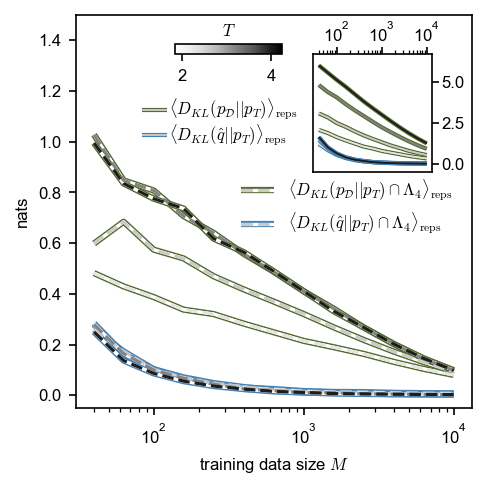

In [13]:
# Reproduce `supp_fig_working-new.pdf` (Appendix D).
fig, ax = subplots(figsize=set_size_for_paper(1, 1.), dpi=150)
fig4_3(ax; inset_loc=(0.6, 0.6, 0.3, 0.3), cb_loc=[0.25, 0.9, 0.27, 0.025],
       axinlegloc=(-1.5, 0.15), legloc=(0.4, 0.42))
ax.set_ylim(-0.05, 1.5)

mkpath(plotsdir("supplemental"))
outpath = plotsdir("supplemental", "supp_fig_reproduced.svg")
savefig(outpath, bbox_inches="tight")
println("saved reproduced supp_fig to: ", outpath)

In [21]:
set_plot_style_for_paper(label_pt=8.)


Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=8.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



saved reproduced fig4 to: /Users/pfields/Git/temp-tune/plots/supplemental/fig4_reproduced.svg


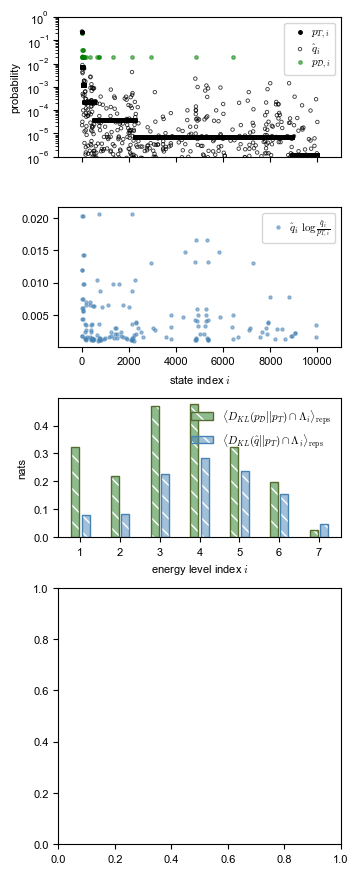

In [24]:
# Reproduce the data panels of `fig4-working-latest.pdf` (Appendix D).
# Panel A: per-state probabilities (true p_T, fit q̂, empirical p_D), sorted by p_T.
# Panel B: per-state contribution to the reversed D_KL.
# Panel C: per-energy-level D_KL decomposition, averaged over replicates (fig4_2).
# (The faint energy-level gridlines in Panel A come from `make_hist_edges`, which needs the
#  Ising src; they are cosmetic and omitted here.)

hd  = hld[:low]                              # low-T experiment: T=2.3, M=54
idx = 1:2^16
idx_ptrue   = sortperm(hd[:ptrue], rev=true)[idx]
qfit_resort = hd[:qfit][idx_ptrue]
pemp_resort = hd[:pemp][idx_ptrue]
pt          = sort(hd[:ptrue], rev=true)[idx]

temp = 2.3
Mnow = 40
emp_p = all_temp_level_dict[temp][:all_dkl_per_lev_emp_p]
emp_q = all_temp_level_dict[temp][:all_dkl_per_lev_emp_q]
q_p   = all_temp_level_dict[temp][:all_dkl_per_lev_q_p]

fig = plt.figure(figsize=set_size_for_paper(1, 2.7), dpi=100)
gs = fig.add_gridspec(4, 1, height_ratios=(1.58/6, 1.58/6, 1.58/6, 2.9/6),
                      left=0.13, right=0.96, bottom=0.05, top=0.95, wspace=0.05, hspace=0.3)
ax = []
push!(ax, fig.add_subplot(gs[1]))   # ax[1] = Panel A (per-state probabilities)
push!(ax, fig.add_subplot(gs[3]))   # ax[2] = Panel C (per-level decomposition)
push!(ax, fig.add_subplot(gs[4]))   # ax[3] = (blank in source layout)
push!(ax, fig.add_subplot(gs[2]))   # ax[4] = Panel B (per-state D_KL contribution)

# Panel C — per-level decomposition
fig4_2(ax[2], emp_p, emp_q, q_p, Mnow; idxscs=2:8)

# Panel B — per-state contribution to reversed D_KL
idcs_show = 1:10000
D_i = (qfit_resort .* log.(qfit_resort ./ pt))[idcs_show]
onlythese = D_i .> 0.001
ax[4].scatter(collect(idcs_show)[onlythese], D_i[onlythese], s=5, color="steelblue", alpha=0.5,
              label=L"\hat{q}_i \ \log \frac{\hat{q}_i}{p_{T,i}}")
ax[4].set_xlabel("state index " * L"i")

# Panel A — per-state probability masses
ax[1].tick_params(labelbottom=false)
ax[1].scatter(collect(idcs_show), pt[idcs_show], color="k", alpha=1, marker=".",
              label=L"p_{T,i}", zorder=100)
onlythese_2 = sort(sample(1:length(idcs_show), 2000, replace=false))
ax[1].scatter(collect(idcs_show)[onlythese_2], qfit_resort[idcs_show][onlythese_2],
              color="none", alpha=0.8, edgecolor="k", marker=".", label=L"\hat q_i",
              linewidths=0.6, zorder=-50)
ax[1].scatter(collect(idcs_show), pemp_resort[idcs_show], color="g", alpha=0.5, marker=".",
              label=L"p_{\mathcal{D},i}")
ax[1].set_yscale("log")
ax[1].set_yticks(10.0 .^ collect(-6:1:0))
ax[1].set_ylim(1e-6, 1.0)
ax[1].set_xlim(-50, idcs_show[end])
ax[1].set_ylabel("probability")
ax[1].legend(handletextpad=0.0, labelspacing=0.1)
ax[4].legend(handletextpad=0.0, labelspacing=0.1)
ax[1].sharex(ax[4])
ax[4].set_xlim((-1000, length(idcs_show) + 1000))

mkpath(plotsdir("supplemental"))
outpath = plotsdir("supplemental", "fig4_reproduced.svg")
savefig(outpath, bbox_inches="tight")
println("saved reproduced fig4 to: ", outpath)
# fig